# Mintavételezési arány beállítása

A `collect_time_evolution1` függvény most már paraméterben tudja fogadni a mintavételezési arányt:
- `sampling_ratio = 10`: minden 10. időlépést ment (alapértelmezett)
- `sampling_ratio = 5`: minden 5. időlépést ment
- `sampling_ratio = 20`: minden 20. időlépést ment

Ezzel jelentősen csökkenthető a memóriaigény és a számítási idő.

# Set Atomic unit system

In [1]:
import atomic_units as au

hb=1.0
m0=8.8
kappa0=2.3 # 4*pi*epsilon0
e0=3.4

unit_sys = au.AtomicUnitSystem(xh=hb, xe=e0, xm=m0, xk=kappa0)

#print(unit_sys)
print(unit_sys.fine_structure_constant)
print(unit_sys.energy_unit.to('eV'))
print(unit_sys.length_unit.to('nm'))

0.007297352569307101 dimensionless
0.12240749165941847 electron_volt
2.340527796123471 nanometer


In [2]:
from utils.grid_utils import SimulationGrid

sim_grid = SimulationGrid(
    x_points=8*1024,
    x_step=0.045,
    t_points=50000,
    t_start=0,
    t_stop=200.0
)

# Egyenletes mintavételezés - ugyanaz a grid, de kevesebb pontból
sim_grid.add_spatial_mask(
    name="uniform_subsampling",
    mask_type="uniform", 
    desired_points=2048
)

print(f"Spatial grid created with {sim_grid.spatial_grid.num} points")
print(f"Uniform subsampling mask created with {len(sim_grid.get_spatial_masked_grid('uniform_subsampling'))} points")
print(f"Temporal grid created with {sim_grid.temporal_grid.delta} time step and {sim_grid.temporal_grid.num} points")



Spatial grid created with 8192 points
Uniform subsampling mask created with 2048 points
Temporal grid created with 0.004 time step and 50000 points


# Set unified grid

### Spatial grid

In [3]:
uxgrid = sim_grid.x.values

print(type(uxgrid))
uxgrid_dx = sim_grid.x.delta
uxgrid_width = sim_grid.x.width
uxgrid_num = sim_grid.x.num

print("Spatial grid:")
print(uxgrid_num, uxgrid_dx, uxgrid_width)
print(type(uxgrid)) 
print(uxgrid.min(), uxgrid.max(), uxgrid[1]-uxgrid[0], uxgrid.size)
print(uxgrid_width)
print(uxgrid_width*unit_sys.length_unit.to('nm'))

<class 'numpy.ndarray'>
Spatial grid:
8192 0.045 368.64
<class 'numpy.ndarray'>
-184.32 184.27499999999998 0.044999999999987494 8192
368.64
862.8121667629563 nanometer


### Spatial mask

In [4]:
import numpy as np

# Mask lekérése a simulation_grid modullal
mask_arr = sim_grid.get_spatial_mask("uniform_subsampling")
print(f"Mask array shape: {mask_arr.shape}")
print(f"Number of True values: {np.sum(mask_arr)}")

# Maszkolt grid lekérése
masked_x = sim_grid.get_spatial_masked_grid("uniform_subsampling")
print(f"Masked grid shape: {masked_x.shape}")

Mask array shape: (8192,)
Number of True values: 2048
Masked grid shape: (2048,)


### Temporal grid

In [5]:
t_start=sim_grid.t.start
t_stop=sim_grid.t.stop
t_num=sim_grid.t.num

utgrid = sim_grid.t.values
utgrid_dt = sim_grid.t.delta

print(uxgrid_dx**2)
print(utgrid_dt)
print(f"Temporal grid: {t_num} points from {t_start} to {t_stop}")

0.002025
0.004
Temporal grid: 50000 points from 0 to 200.0


In [6]:
import quantum_toolkit as quat
# Create a dispersion object with the specified grid spacing
dispersion=quat.CosineDispersion(uxgrid_dx, hbar = unit_sys.hb, mass = unit_sys.me)

# Set model-potential

8.169434619102878
0.0
0.12240749165941847
1.2817621755950894
4.272540585316965


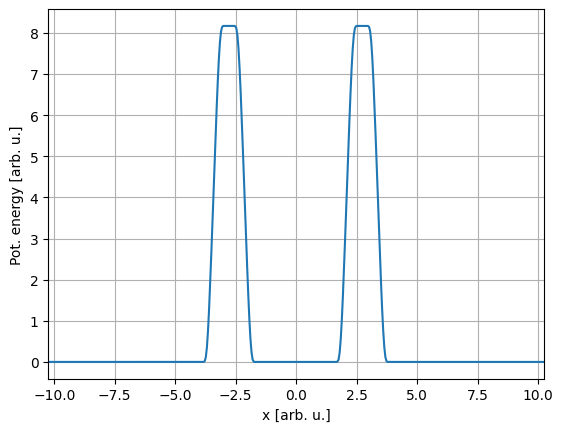

In [7]:
import matplotlib.pyplot as plt
from quantum_toolkit import potentials as pots
import pint


wall_in_unit_sys = 1.0 * unit_sys.convert_energy_from('eV')
print(wall_in_unit_sys)


well_in_unit_sys = 0.0 * unit_sys.convert_energy_from('eV')
print(well_in_unit_sys)

energy_unit_in_ev = unit_sys.energy_unit.to('eV').magnitude
print(energy_unit_in_ev)
length_unit_in_nm = unit_sys.length_unit.to('nm').magnitude


wall_width = 3 * unit_sys.convert_length_from('nm')
print(wall_width)
well_width = 10 * unit_sys.convert_length_from('nm')
print(well_width)

cell_width_au = 2* wall_width + well_width 
cell_width_nm = cell_width_au * length_unit_in_nm

modelpot=pots.SmoothStackPotential(uxgrid,wallwidth=wall_width,\
                                   wallheight=wall_in_unit_sys,\
                                   welldepth=well_in_unit_sys,\
                                   wellwidth=well_width,\
                                   wallrise = 1,\
                                   wellfall = 1)
#modelpot=StackPotential(uxgrid)

plt.plot(uxgrid,modelpot(0))
plt.xlabel("x [arb. u.]")
plt.ylabel("Pot. energy [arb. u.]")
plt.xlim([-1.5*cell_width_au, 1.5*cell_width_au])
plt.grid()
plt.show()

/opt/homebrew/lib/python3.11/site-packages/matplotlib/cbook/__init__.py:1335: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  return np.asarray(x, float)


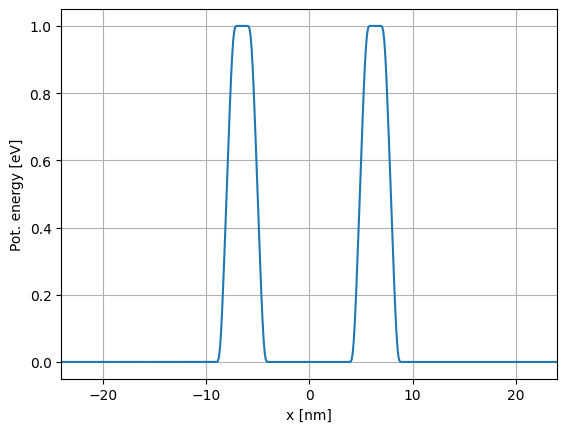

In [8]:
x = uxgrid * unit_sys.length_unit.to('nm')
y = modelpot(0) * unit_sys.energy_unit.to('eV')

plt.plot(x, y)
plt.xlabel("x [nm]")
plt.ylabel("Pot. energy [eV]")
plt.xlim([-1.5*cell_width_nm, 1.5*cell_width_nm])
plt.grid()
plt.show()

In [9]:
zeropot=pots.ZeroPotential(uxgrid)

ham_static = quat.HamiltonOperator(uxgrid,hbar=unit_sys.hb,\
                                   me=unit_sys.me,\
                                   charge=unit_sys.e0,\
                                   scalarpot=modelpot, vectorpot=zeropot )

In [10]:
t_vals=[]
r_vals=[]

energy_min = 0.9
energy_max = 1.4
number_of_points_in_energy = 11

energy_min_in_unit_sys = energy_min*unit_sys.convert_energy_from('eV')
energy_max_in_unit_sys = energy_max*unit_sys.convert_energy_from('eV')

k_min = dispersion.wavenumber(energy_min_in_unit_sys)
k_max = dispersion.wavenumber(energy_max_in_unit_sys)

k_vals=np.linspace(k_min,k_max,number_of_points_in_energy)

print(k_min,k_max,k_vals)

e_vals=[]

quasiparticles_pk=[]
quasiparticles_mk=[]

for k in k_vals:

    kin=k
    ein=dispersion.energy(k)
    e_vals.append(ein)

    qp_pk, qp_mk = quat.quasiparticles_at_given_energy(ein,kin,ham_static)
    quasiparticles_pk.append(qp_pk)
    quasiparticles_mk.append(qp_mk)

    t_vals.append(qp_pk.transmission)
    r_vals.append(qp_pk.reflection)

    print(kin)

    num=len(t_vals)

    # plt.plot(k_vals[:num],t_vals,"-o",label="T")
    # plt.plot(k_vals[:num],r_vals,"-o",label="R")
    # plt.xlabel("k [arb. u.]")
    # #plt.ylabel("Coefficient")
    # plt.legend()
    # plt.grid()
    # plt.show()

11.503595731504609 14.440583059613678 [11.50359573 11.79729446 12.0909932  12.38469193 12.67839066 12.9720894
 13.26578813 13.55948686 13.85318559 14.14688433 14.44058306]
11.503595731504609
11.503595731504609
11.797294464315515
11.797294464315515
12.090993197126423
12.090993197126423
12.384691929937329
12.384691929937329
12.678390662748237
12.678390662748237
12.972089395559143
12.972089395559143
13.265788128370051
13.265788128370051
13.559486861180957
13.559486861180957
13.853185593991864
13.853185593991864
14.146884326802772
14.146884326802772
14.440583059613678
14.440583059613678


In [11]:
import h5py

output_file = "quasiparticles_wall.h5"
with h5py.File(output_file, "w") as hdf:
    grp_particles = hdf.create_group("particles")
    for i, (qp_pk, qp_mk) in enumerate(zip(quasiparticles_pk, quasiparticles_mk)):
        grp_index = grp_particles.create_group(f"{i}.")
        grp_index.attrs["energy"] = qp_pk.angular_frequency * unit_sys.hb

        # Save particle with positive k using QuasiParticle method
        pk_grp = grp_index.create_group("positive_k")
        qp_pk.to_hdf5_group(pk_grp)

        # Save particle with negative k using QuasiParticle method
        mk_grp = grp_index.create_group("negative_k")
        qp_mk.to_hdf5_group(mk_grp)
        
print(f"Saved to {output_file}")

Saved to quasiparticles_wall.h5


In [12]:
def load_quasiparticles_from_hdf5(filename):
    quasiparticles_pk = []
    quasiparticles_mk = []
    e_vals = []
    k_vals = []
    t_vals=[]
    r_vals=[]
    import h5py
    from quantum_toolkit.quantum_transport_toolkit import QuasiParticle
    with h5py.File(filename, "r") as hdf:
        particles_group = hdf["particles"]
        # --- csoportnevek rendezése numerikusan ---
        group_names = sorted(particles_group.keys(), key=lambda x: int(x.rstrip('.')))
        for group_name in group_names:
            group = particles_group[group_name]
            e_vals.append(group.attrs["energy"])
            print(f"Processing group: {group_name}, energy: {group.attrs['energy']}")
            # Positive k
            pk = QuasiParticle.from_hdf5_group(group["positive_k"])
            # Negative k
            mk = QuasiParticle.from_hdf5_group(group["negative_k"])
            k_vals.append(pk.wavenumber)
            t_vals.append(pk.transmission)
            r_vals.append(pk.reflection)
            quasiparticles_pk.append(pk)
            quasiparticles_mk.append(mk)
    return e_vals, k_vals, t_vals, r_vals, quasiparticles_pk, quasiparticles_mk

# Példa használat:
e_vals, k_vals, t_vals, r_vals, quasiparticles_pk, quasiparticles_mk = load_quasiparticles_from_hdf5("quasiparticles_wall.h5")

Processing group: 0., energy: 7.35249115719259
Processing group: 1., energy: 7.723751250801077
Processing group: 2., energy: 8.103464232937124
Processing group: 3., energy: 8.491563778442147
Processing group: 4., energy: 8.887982097261288
Processing group: 5., energy: 9.292649946284367
Processing group: 6., energy: 9.705496641440744
Processing group: 7., energy: 10.126450070045813
Processing group: 8., energy: 10.555436703397067
Processing group: 9., energy: 10.992381609617485
Processing group: 10., energy: 11.43720846674403


In [13]:
print(e_vals)

[7.35249115719259, 7.723751250801077, 8.103464232937124, 8.491563778442147, 8.887982097261288, 9.292649946284367, 9.705496641440744, 10.126450070045813, 10.555436703397067, 10.992381609617485, 11.43720846674403]


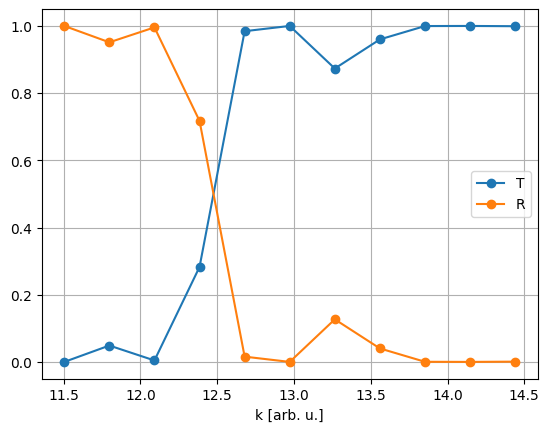

In [14]:
plt.plot(k_vals,t_vals,"-o",label="T")
plt.plot(k_vals,r_vals,"-o",label="R")
plt.xlabel("k [arb. u.]")
#plt.ylabel("Coefficient")
plt.legend()
plt.grid()
plt.show()

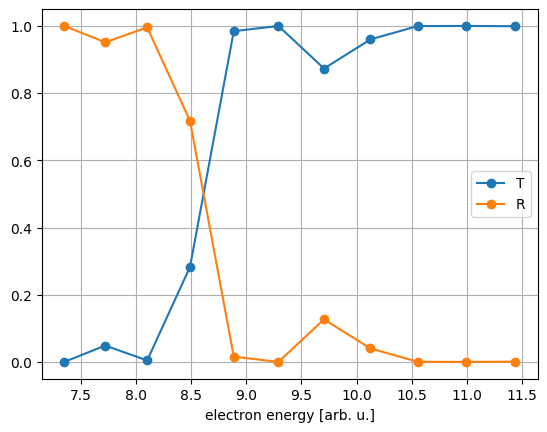

In [15]:
plt.plot(e_vals,t_vals,"-o",label="T")
plt.plot(e_vals,r_vals,"-o",label="R")
plt.xlabel("electron energy [arb. u.]")
#plt.ylabel("Coefficient")
plt.legend()
plt.grid()
plt.show()

# Laser potential

In [16]:
spot_size_nm = 400 # in nm
magnitude_of_electric_field_gvm = 1.0 # in GV/m
central_wavelength_nm = 800 # in nm

In [17]:
import numpy as np

central_wavelength = central_wavelength_nm*unit_sys.convert_length_from("nm")
print(central_wavelength)

omega = 2*np.pi*unit_sys.speed_of_light/central_wavelength_nm
print(omega)
num_of_cycles = 5 # one cycle is around 2.66 fs

t_min = 0
t_max = num_of_cycles*2*np.pi/omega
print("pulse length hus:",t_max,t_max*unit_sys.time_unit.to("fs"))

s_min = -0.5*spot_size_nm*unit_sys.convert_length_from("nm")
s_max = 0.5*spot_size_nm*unit_sys.convert_length_from("nm")
print("spot size:",s_min,s_max)


magnitude = magnitude_of_electric_field_gvm*unit_sys.convert_electric_field_from("GV/m")
print(magnitude)

beta=0.2

laserpot = pots.SmoothLaserPotential(uxgrid, spatial_min = s_min, spatial_max = s_max,\
                                            temporal_max=t_max,temporal_min=t_min,noc=num_of_cycles,\
                                            amplitude=magnitude,beta=beta)

laserpot_masked = pots.SmoothLaserPotential(uxgrid[mask_arr], spatial_min = s_min, spatial_max = s_max,\
                                            temporal_max=t_max,temporal_min=t_min,noc=num_of_cycles,\
                                            amplitude=magnitude,beta=beta)

print(laserpot.omega0)

341.8032468253572
5.409467923108539
pulse length hus: 5.807581629552364 31.228641464002013 femtosecond
spot size: -85.4508117063393 85.4508117063393
5.623761413124601
5.409467923108539


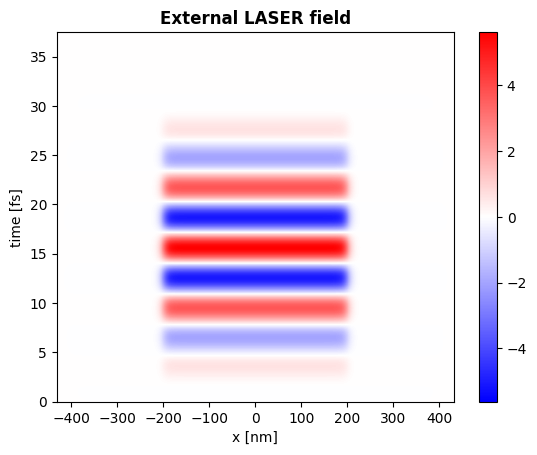

In [18]:
X,Y = np.meshgrid(uxgrid[mask_arr],utgrid)
X_nm,Y_fs = np.meshgrid(uxgrid[mask_arr]*unit_sys.length_unit.to('nm').magnitude,\
                  utgrid*unit_sys.time_unit.to('fs').magnitude)

Z=laserpot_masked(Y)

z_min, z_max = -np.abs(Z).max(), np.abs(Z).max()
    
pcm = plt.pcolormesh(X_nm, Y_fs, Z, cmap ='bwr', vmin = z_min, vmax = z_max)
plt.colorbar(pcm)
 
plt.title('External LASER field', fontweight ="bold")
plt.ylim(0.0,1.2*laserpot_masked.temporal_max*unit_sys.time_unit.to('fs').magnitude)
#plt.xlim(2*laserpot_cep0.spatial_min,2*laserpot_cep0.spatial_max)
plt.xlabel("x [nm]")
plt.ylabel("time [fs]")
plt.show()

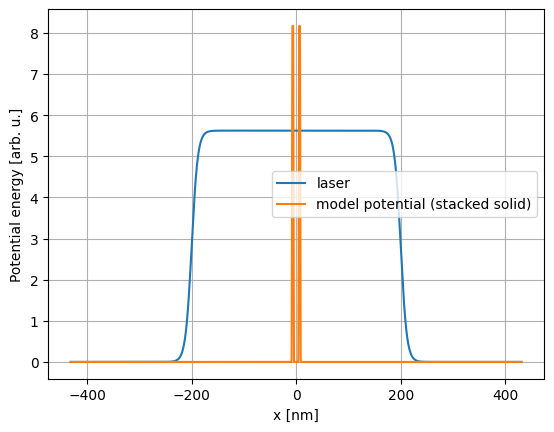

In [19]:
plt.plot(uxgrid[mask_arr]*unit_sys.length_unit.to("nm"),\
          laserpot_masked(laserpot.temporal_width/2),label="laser")
plt.plot(uxgrid*unit_sys.length_unit.to("nm"),\
          modelpot(uxgrid[mask_arr]),label="model potential (stacked solid)")
#plt.xlim([-0.8*modelpot.wellwidth, 0.8*modelpot.wellwidth])
plt.legend()
plt.xlabel("x [nm]")
plt.ylabel("Potential energy [arb. u.]")
plt.grid()
plt.show()

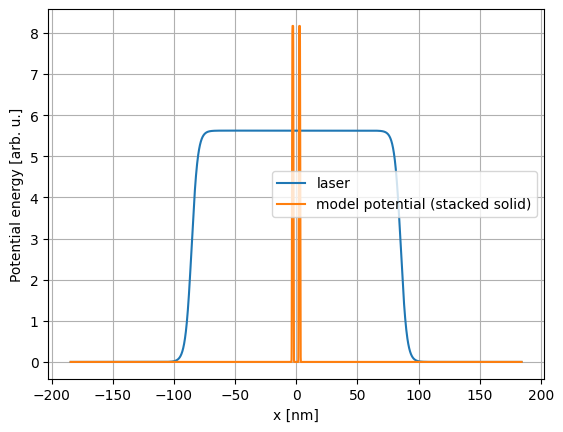

In [20]:
plt.plot(uxgrid[mask_arr],\
          laserpot_masked(laserpot.temporal_width/2),label="laser")
plt.plot(uxgrid,\
          modelpot(uxgrid[mask_arr]),label="model potential (stacked solid)")
#plt.xlim([-0.8*modelpot.wellwidth, 0.8*modelpot.wellwidth])
plt.legend()
plt.xlabel("x [nm]")
plt.ylabel("Potential energy [arb. u.]")
plt.grid()
plt.show()

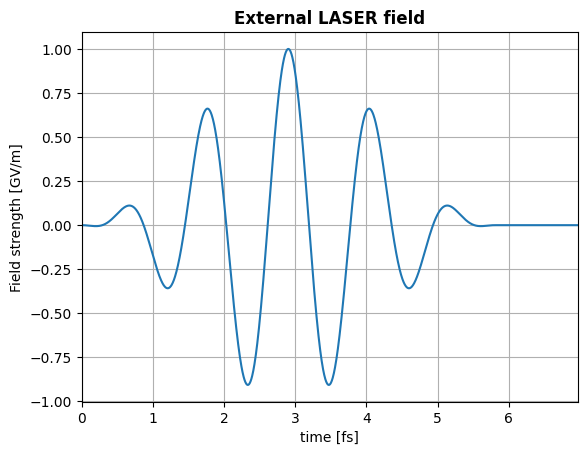

In [21]:
plt.plot(utgrid,\
          laserpot.value_at(0.0,utgrid)*unit_sys.electric_field_unit.to('GV/m'),\
          label="laser")
plt.xlabel("time [fs]")
plt.ylabel("Field strength [GV/m]")
plt.title('External LASER field', fontweight ="bold")
plt.xlim(0,1.2*laserpot.temporal_width)
plt.grid()
plt.show()

# Select initial state

8.887982097261288 1.0879555944395718 electron_volt
12.678390662748237 5.416893866309549 / nanometer


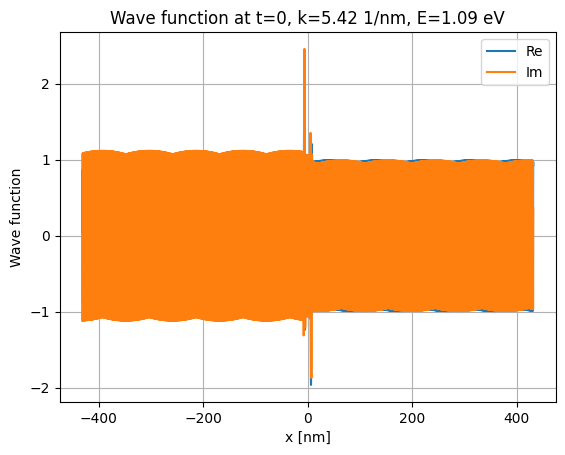

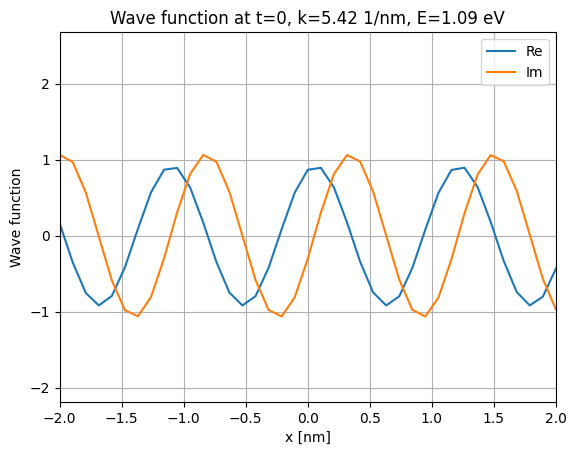

In [22]:
from quantum_toolkit import quantum_transport_toolkit as trat

qp_index = 4

qppk, qpmk = quasiparticles_pk[qp_index], quasiparticles_mk[qp_index]

ein=qppk.angular_frequency * unit_sys.hb
kin=qppk.wavenumber

print(ein,ein*unit_sys.energy_unit.to('eV'))
print(kin,kin*unit_sys.wavenumber_unit.to('1/nm'))

initial_state = qppk.state

plt.plot(uxgrid*unit_sys.length_unit.to('nm'),\
          np.real(initial_state.value),label="Re")
plt.plot(uxgrid*unit_sys.length_unit.to('nm'),\
          np.imag(initial_state.value),label="Im")
plt.xlabel("x [nm]")
plt.ylabel("Wave function")
plt.title(f"Wave function at t=0, k={kin*unit_sys.wavenumber_unit.to('1/nm').magnitude:.2f} 1/nm, E={ein*unit_sys.energy_unit.to('eV').magnitude:.2f} eV")
plt.legend()
plt.grid()
plt.show()

plt.plot(uxgrid*unit_sys.length_unit.to('nm'),\
          np.real(initial_state.value),label="Re")
plt.plot(uxgrid*unit_sys.length_unit.to('nm'),\
          np.imag(initial_state.value),label="Im")
plt.xlabel("x [nm]")
plt.xlim([-2, 2])
plt.ylabel("Wave function")
plt.title(f"Wave function at t=0, k={kin*unit_sys.wavenumber_unit.to('1/nm').magnitude:.2f} 1/nm, E={ein*unit_sys.energy_unit.to('eV').magnitude:.2f} eV")
plt.legend()
plt.grid()
plt.show()

# Vcap check

In [23]:
v_cap=quat.vcap_generator(uxgrid,param_x0=145,param_lambda0 = 0.15)

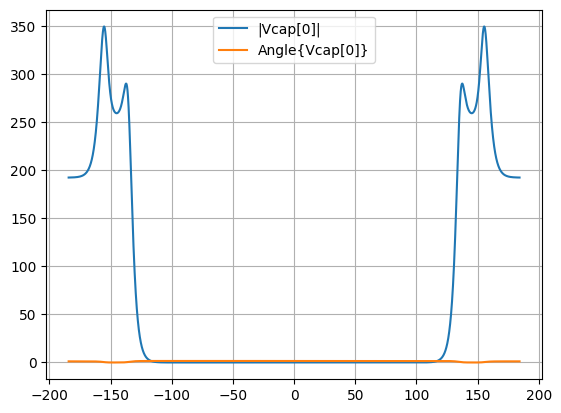

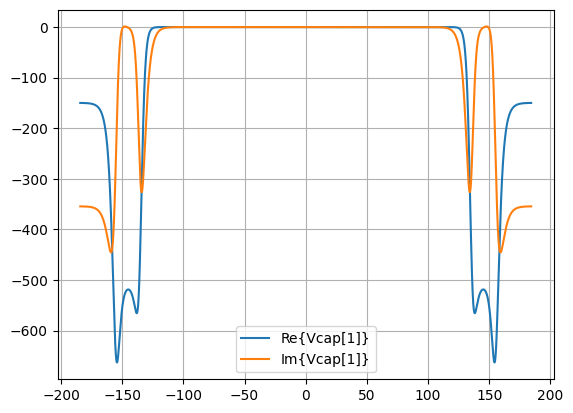

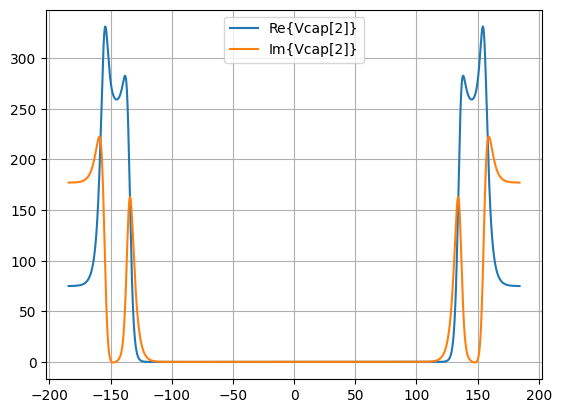

In [24]:
plt.plot(uxgrid,np.abs(v_cap[0]),label="|Vcap[0]|")
plt.plot(uxgrid,np.angle(v_cap[0]),label="Angle{Vcap[0]}")
plt.legend()
plt.grid()
plt.show()

plt.plot(uxgrid,np.real(v_cap[1]),label="Re{Vcap[1]}")
plt.plot(uxgrid,np.imag(v_cap[1]),label="Im{Vcap[1]}")
plt.legend()
plt.grid()
plt.show()

plt.plot(uxgrid,np.real(v_cap[2]),label="Re{Vcap[2]}")
plt.plot(uxgrid,np.imag(v_cap[2]),label="Im{Vcap[2]}")
plt.legend()
plt.grid()
plt.show()

In [25]:
# Időfejlődés observeres megközelítéssel
# Mintavételezési arány (alapértelmezetten minden 10. időlépést mentjük)
sampling_ratio = 10

def collect_time_evolution1(psi0_grid, psi1_grid, psi_grid, uxgrid, t, i, utgrid, psi_arr, psi1_arr, ratio=10):
    # Csak minden ratio-dik időlépést mentjük ki
    if i % ratio == 0:
        time_index = i // ratio  # Az új indexelés
        psi_arr[:, time_index] = psi_grid
        #psi0_arr[:, time_index] = psi0_grid  # psi0 is not used in this case, so we can skip it
        psi1_arr[:, time_index] = psi1_grid

# Előre allokált tömbök létrehozása
num_x = len(uxgrid)
num_t = len(utgrid) // sampling_ratio  # A sampling_ratio szerint csökkentjük a tárolási igényt
psi_pk_te_arr1 = np.zeros((num_x, num_t), dtype=np.complex128)
#psi0_pk_te_arr1 = np.zeros((num_x, num_t), dtype=np.complex128)
psi1_pk_te_arr1 = np.zeros((num_x, num_t), dtype=np.complex128)
psi_mk_te_arr1 = np.zeros((num_x, num_t), dtype=np.complex128)
#psi0_mk_te_arr1 = np.zeros((num_x, num_t), dtype=np.complex128)
psi1_mk_te_arr1 = np.zeros((num_x, num_t), dtype=np.complex128)

# Csökkentett időrács a plot-oláshoz
utgrid_reduced = utgrid[::sampling_ratio]

In [26]:
# Calculator1 létrehozása és futtatása pozitív k esetében
calculator1_pk = quat.SplitTimeEvolutionCalculator(
    psi0_omega=qppk.angular_frequency,
    psi0_initial=qppk.state,
    scalarpot=modelpot,
    vectorpot=laserpot,
    dt=utgrid_dt, t_start=t_start, t_stop=t_stop,
    vcap=v_cap,
    me=unit_sys.me,
    hbar=unit_sys.hb,
    charge=unit_sys.e0
)

# Futtatás observerrel, eredmények gyűjtése a tömbökbe
calculator1_pk.run(lambda psi0, psi1, psi, uxgrid, t, i, utgrid: collect_time_evolution1(
    psi0, psi1, psi, uxgrid, t, i, utgrid, psi_pk_te_arr1, psi1_pk_te_arr1, sampling_ratio
))

# Calculator1 létrehozása és futtatása negatív k esetében
calculator1_mk = quat.SplitTimeEvolutionCalculator(
    psi0_omega=qpmk.angular_frequency,
    psi0_initial=qpmk.state,
    scalarpot=modelpot,
    vectorpot=laserpot,
    dt=utgrid_dt, t_start=t_start, t_stop=t_stop,
    vcap=v_cap,
    me=unit_sys.me,
    hbar=unit_sys.hb,
    charge=unit_sys.e0
)

# Futtatás observerrel, eredmények gyűjtése a tömbökbe
calculator1_mk.run(lambda psi0, psi1, psi, uxgrid, t, i, utgrid: collect_time_evolution1(
    psi0, psi1, psi, uxgrid, t, i, utgrid, psi_mk_te_arr1, psi1_mk_te_arr1, sampling_ratio
))

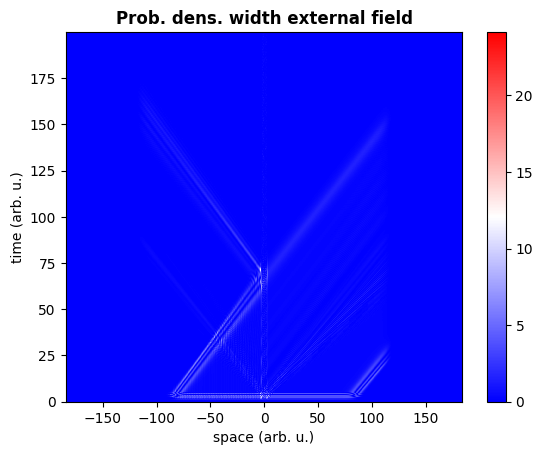

In [27]:
# Valószínűségi sűrűség kirajzolása observeres időfejlődésből
X, Y = np.meshgrid(uxgrid[mask_arr], utgrid_reduced)
Z = np.abs(psi1_pk_te_arr1[mask_arr, :])**2  # shape: (space, time)

pcm = plt.pcolormesh(X, Y, Z.T, cmap='bwr')
plt.colorbar(pcm)
plt.title('Prob. dens. width external field', fontweight="bold")
plt.xlabel("space (arb. u.)")
plt.ylabel("time (arb. u.)")
#plt.ylim([0,25])
plt.show()

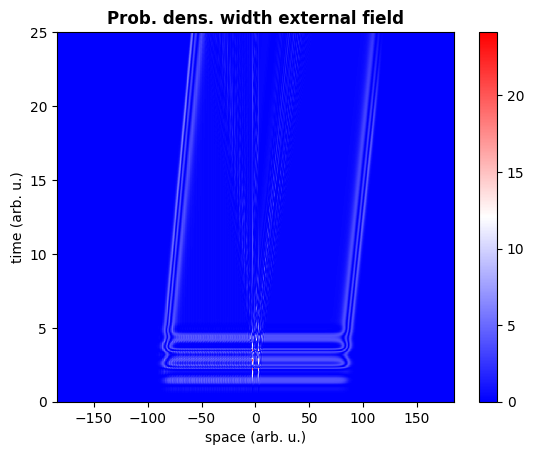

In [28]:
# Valószínűségi sűrűség kirajzolása observeres időfejlődésből
X, Y = np.meshgrid(sim_grid.get_spatial_masked_grid("uniform_subsampling"), utgrid_reduced)
Z = np.abs(psi1_pk_te_arr1[sim_grid.get_spatial_mask("uniform_subsampling"),:])**2  # shape: (space, time)

pcm = plt.pcolormesh(X, Y, Z.T, cmap='bwr')
plt.colorbar(pcm)
plt.title('Prob. dens. width external field', fontweight="bold")
plt.xlabel("space (arb. u.)")
plt.ylabel("time (arb. u.)")
plt.ylim([0,25])
plt.show()

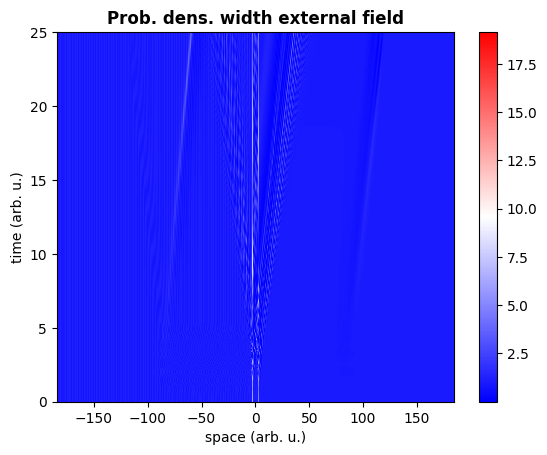

In [29]:
# Valószínűségi sűrűség kirajzolása observeres időfejlődésből
X, Y = np.meshgrid(sim_grid.get_spatial_masked_grid("uniform_subsampling"), utgrid_reduced)
Z = np.abs(psi_pk_te_arr1[sim_grid.get_spatial_mask("uniform_subsampling"),:])**2  # shape: (space, time)

pcm = plt.pcolormesh(X, Y, Z.T, cmap='bwr')
plt.colorbar(pcm)
plt.title('Prob. dens. width external field', fontweight="bold")
plt.xlabel("space (arb. u.)")
plt.ylabel("time (arb. u.)")
plt.ylim([0,25])
plt.show()

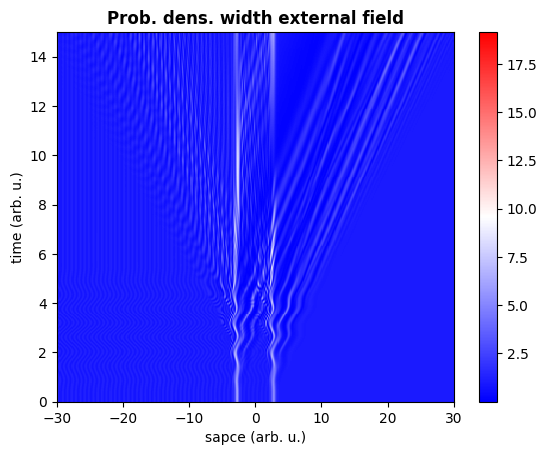

In [30]:
X,Y = np.meshgrid(sim_grid.get_spatial_masked_grid("uniform_subsampling"),utgrid_reduced)

psi_pk_te_wf = quat.Wavefunction(grid=sim_grid.get_spatial_masked_grid("uniform_subsampling"), value=psi_pk_te_arr1[sim_grid.get_spatial_mask("uniform_subsampling"),:])

Z=np.transpose(quat.probability_density(psi_pk_te_wf))
#Z=np.transpose(np.real(masked_psi_pk_te.psi1_time_evolution))

#z_min, z_max = -np.abs(Z).max(), np.abs(Z).max()
    
pcm = plt.pcolormesh(X,Y,Z,cmap ='bwr') #plt.pcolormesh(X, Y, Z, cmap ='bwr', vmin = z_min, vmax = z_max)
plt.colorbar(pcm)

plt.title('Prob. dens. width external field', fontweight ="bold")
plt.xlabel("sapce (arb. u.)")
plt.ylabel("time (arb. u.)")
plt.xlim([-30, 30])
plt.ylim([0,15])
plt.show()

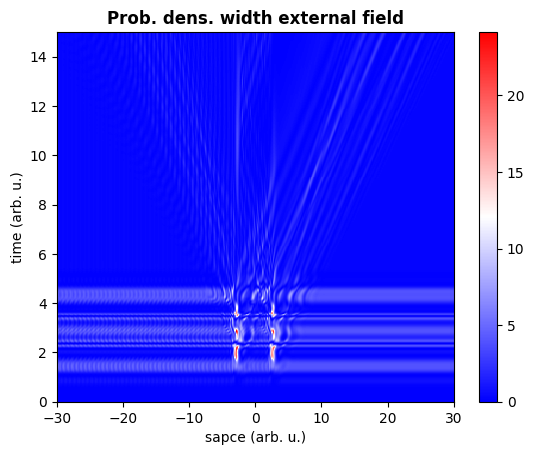

In [31]:
X,Y = np.meshgrid(sim_grid.get_spatial_masked_grid("uniform_subsampling"),utgrid_reduced)

psi1_pk_te_wf = quat.Wavefunction(grid=sim_grid.get_spatial_masked_grid("uniform_subsampling"), value=psi1_pk_te_arr1[sim_grid.get_spatial_mask("uniform_subsampling"),:])

Z=np.transpose(quat.probability_density(psi1_pk_te_wf))
#Z=np.transpose(np.real(masked_psi_pk_te.psi1_time_evolution))

#z_min, z_max = -np.abs(Z).max(), np.abs(Z).max()
    
pcm = plt.pcolormesh(X,Y,Z,cmap ='bwr') #plt.pcolormesh(X, Y, Z, cmap ='bwr', vmin = z_min, vmax = z_max)
plt.colorbar(pcm)

plt.title('Prob. dens. width external field', fontweight ="bold")
plt.xlabel("sapce (arb. u.)")
plt.ylabel("time (arb. u.)")
plt.xlim([-30, 30])
plt.ylim([0,15])
plt.show()

In [32]:
# Kezdőállapot (t=0) sűrűség
psi_0 = qppk.state.value
density_0 = np.abs(psi_0)**2
norm_0 = np.trapz(density_0, uxgrid)

# Időfejlesztett állapot utolsó időpontban
psi_final = psi_pk_te_arr1[:,-1]
density_final = np.abs(psi_final)**2
norm_final = np.trapz(density_final, uxgrid)

# Különbség és relatív eltérés
abs_diff = np.abs(norm_final - norm_0)
rel_diff = abs_diff / norm_0 if norm_0 != 0 else np.nan

print(f"Norm (t=0): {norm_0:.6g}, Norm (final): {norm_final:.6g}")
print(f"Abs diff: {abs_diff:.3e}, Rel diff: {rel_diff:.3e}")

Norm (t=0): 374.189, Norm (final): 375.011
Abs diff: 8.224e-01, Rel diff: 2.198e-03


# Compute probability current

In [33]:
# choose masurement points on the right and the left side
meas_point_right=100
meas_point_left=-meas_point_right

In [34]:


left_index = np.abs(np.array(uxgrid) - meas_point_left).argmin()#1300
right_index = np.abs(np.array(uxgrid) - meas_point_right).argmin()#
x_left = uxgrid[left_index]
x_right = uxgrid[right_index]

print(left_index,right_index)
print(x_left,x_right)

1874 6318
-99.99 99.99000000000001


In [35]:
pc_pk_left=quat.probability_current_at(quat.Wavefunction(grid=uxgrid,value=psi_pk_te_arr1),left_index)
pc_mk_left=quat.probability_current_at(quat.Wavefunction(grid=uxgrid,value=psi_mk_te_arr1),left_index)
pc_pk_right=quat.probability_current_at(quat.Wavefunction(grid=uxgrid,value=psi_pk_te_arr1),right_index)
pc_mk_right=quat.probability_current_at(quat.Wavefunction(grid=uxgrid,value=psi_mk_te_arr1),right_index)


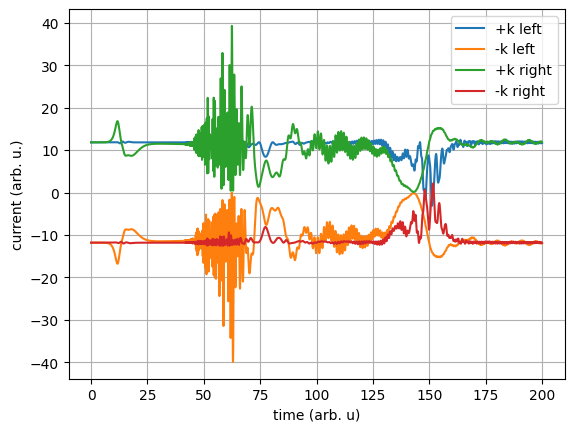

In [36]:
plt.plot(utgrid_reduced, pc_pk_left,label="+k left")
plt.plot(utgrid_reduced, pc_mk_left,label="-k left")
plt.plot(utgrid_reduced, pc_pk_right,label="+k right")
plt.plot(utgrid_reduced, pc_mk_right,label="-k right")
#plt.plot(utgrid, pcsum_diff,label="current difference")
plt.xlabel("time (arb. u)")
plt.ylabel("current (arb. u.)")
#plt.xlim(0,40)
plt.legend()
#plt.ylim(-1e-5,1e-5)
plt.grid()
plt.show()

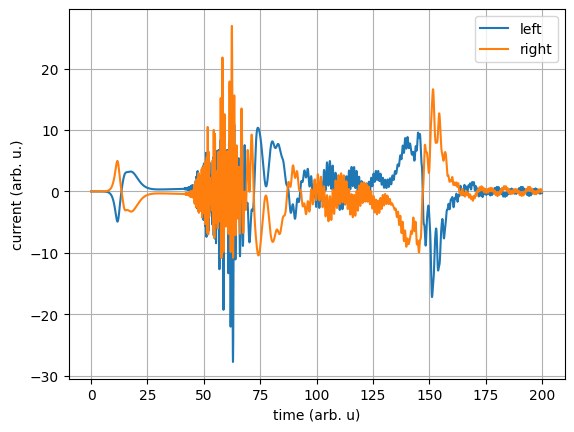

In [37]:
pc_left = pc_pk_left + pc_mk_left
pc_right = pc_pk_right + pc_mk_right
plt.plot(utgrid_reduced, pc_left,label="left")
plt.plot(utgrid_reduced, pc_right,label="right")
#plt.plot(utgrid, pcsum_diff,label="current difference")
plt.xlabel("time (arb. u)")
plt.ylabel("current (arb. u.)")
#plt.xlim(0,40)
plt.legend()
#plt.ylim(-1e-5,1e-5)
plt.grid()
plt.show()

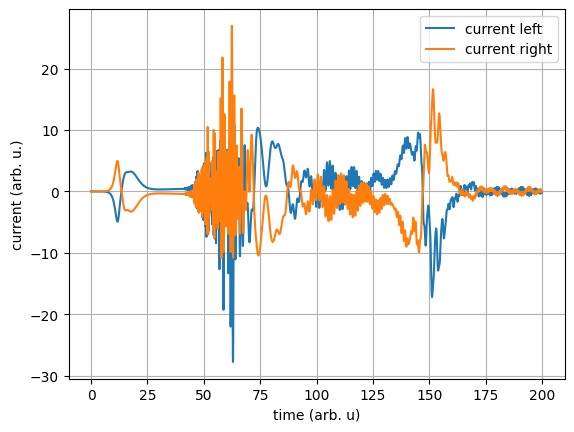

In [38]:
pc_sum_left=pc_left#pc_sum[left_index,:]
pc_sum_right=pc_right#pc_sum[right_index,:]
#pcsum_diff=pcsum_right-pcsum_left

plt.plot(utgrid_reduced, pc_sum_left,label="current left")
plt.plot(utgrid_reduced, pc_sum_right,label="current right")
#plt.plot(utgrid, pcsum_diff,label="current difference")
plt.xlabel("time (arb. u)")
plt.ylabel("current (arb. u.)")
#plt.xlim(0,40)
plt.legend()
#plt.ylim(-1e-5,1e-5)
plt.grid()
plt.show()

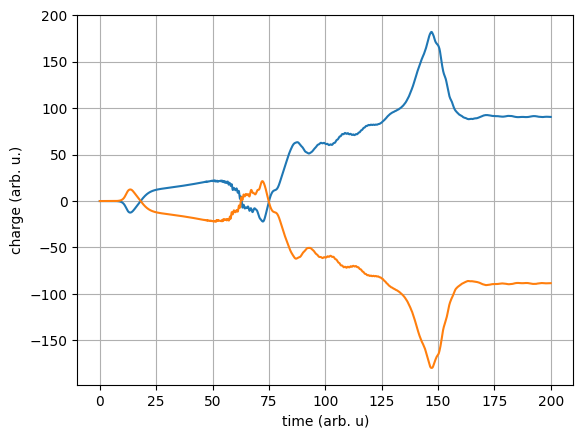

In [39]:
from scipy import integrate

charge_left = integrate.cumtrapz(pc_sum_left, utgrid_reduced, initial=0)
charge_right = integrate.cumtrapz(pc_sum_right, utgrid_reduced, initial=0)
#charge_diff = integrate.cumtrapz(pcsum_diff, utgrid, initial=0)

plt.plot(utgrid_reduced, charge_left,label="charge left")
plt.plot(utgrid_reduced, charge_right,label="charge right")
#plt.plot(utgrid, charge_left+charge_right)
#plt.plot(utgrid, charge_diff)
plt.xlabel("time (arb. u)")
plt.ylabel("charge (arb. u.)")
#plt.xlim(100)
#plt.ylim(-1e-3,1e-3)
plt.grid()
plt.show()